# 🏃 Human Action Recognition — EfficientNetB3 + PGM Models
**EfficientNetB3 · Naive Bayes · Bayesian Network · Hidden Markov Model**
### Strategy
- ✅ **EfficientNetB3** (Deep Learning baseline — image-based)
- ✅ **Naive Bayes** (PGM — engineered features)
- ✅ **Bayesian Network** (PGM via pgmpy — conditional dependencies)
- ✅ **Hidden Markov Model** (PGM via hmmlearn — sequential transitions)
- ✅ Side-by-side comparison: Accuracy, F1, Confusion Matrix
- ✅ Per-image prediction with **reasoning** from PGM models


## 📦 Cell 1 — Install Dependencies (Kaggle)


In [1]:
# Install PGM libraries (Kaggle — no Drive mount needed)
import subprocess
subprocess.run(['pip', 'install', 'pgmpy', 'hmmlearn', '-q'], check=True)
print("Dependencies installed ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.6 MB/s eta 0:00:00
Dependencies installed ✅


## 📦 Cell 2 — Imports & GPU Config

In [2]:
import os, random, gc, warnings, json, pickle
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

# PGM imports
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from hmmlearn import hmm

# ── GPU ──────────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f'GPUs found: {len(gpus)} →', gpus)

mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy())

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)
print('Setup complete ✅')


2026-05-14 04:35:38.930292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778733339.327546      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778733339.434222      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778733340.457444      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778733340.457485      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778733340.457488      57 computation_placer.cc:177] computation placer alr

GPUs found: 2 → [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
TensorFlow version: 2.19.0
Setup complete ✅


## 📁 Cell 3 — Paths (Edit BASE_DIR if needed)

In [4]:
BASE_DIR      = '/kaggle/input/datasets/meetnagadia/human-action-recognition-har-dataset/Human Action Recognition'
TRAIN_IMG_DIR = BASE_DIR + '/train'
TRAIN_CSV     = BASE_DIR + '/Training_set.csv'
CHECKPOINT    = '/kaggle/working/best_har_effnetb3.weights.h5'
VAL_CACHE     = '/kaggle/working/val_cache'

# Model save paths
NB_MODEL_PATH  = '/kaggle/working/nb_model.pkl'
BN_MODEL_PATH  = '/kaggle/working/bn_model.pkl'
HMM_MODEL_PATH = '/kaggle/working/hmm_model.pkl'

os.makedirs('/kaggle/working', exist_ok=True)

for p in [TRAIN_CSV, TRAIN_IMG_DIR]:
    status = '✅' if os.path.exists(p) else '❌ NOT FOUND'
    print(f'{status}  {p}')


✅  /kaggle/input/datasets/meetnagadia/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv
✅  /kaggle/input/datasets/meetnagadia/human-action-recognition-har-dataset/Human Action Recognition/train


## 📊 Cell 4 — Load Data (Stratified 10k Sample)

Total samples: 12600 | Classes: 15
Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Train: 8000 | Val: 2000


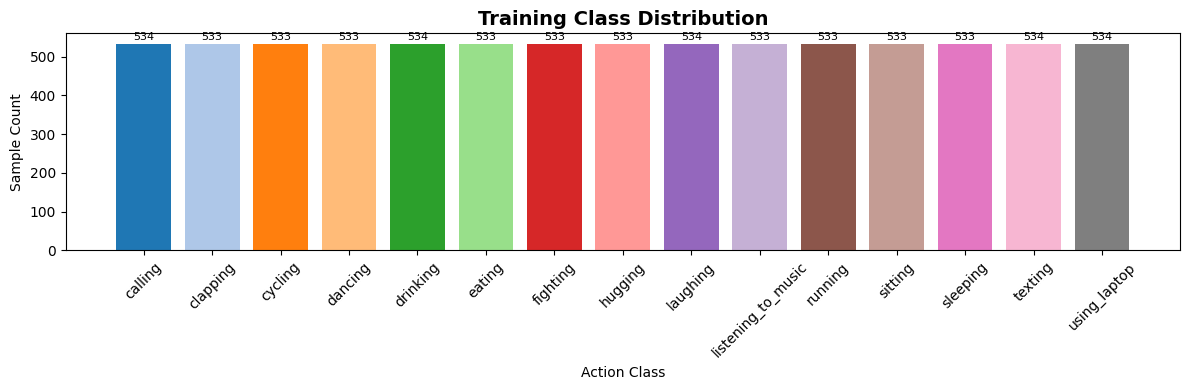

In [5]:
df = pd.read_csv(TRAIN_CSV)
df.columns = [c.strip().lower() for c in df.columns]
df['filepath'] = df['filename'].map(lambda x: os.path.join(TRAIN_IMG_DIR, x))
df = df[df['filepath'].map(os.path.exists)].reset_index(drop=True)

CLASS_NAMES = sorted(df['label'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f'Total samples: {len(df)} | Classes: {NUM_CLASSES}')
print('Classes:', CLASS_NAMES)

SAMPLE_SIZE = 10000
if len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE,
                              stratify=df['label'], random_state=SEED)
    df = df.reset_index(drop=True)

train_df, val_df = train_test_split(df, train_size=0.8,
                                     stratify=df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)}')

# Class distribution chart
fig, ax = plt.subplots(figsize=(12, 4))
counts = train_df['label'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab20.colors[:NUM_CLASSES])
ax.set_title('Training Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Action Class'); ax.set_ylabel('Sample Count')
ax.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


## 🔧 Cell 5 — Image Feature Engineering (for PGM Models)
PGM models work on **hand-crafted features** extracted from images — they cannot directly use raw pixels.
We extract 7 interpretable features per image:
- `brightness`: mean pixel intensity
- `contrast`: std deviation of pixel intensity
- `r_mean / g_mean / b_mean`: per-channel average colour
- `edge_density`: fraction of edge pixels (Sobel-based)
- `saturation`: mean HSV saturation


In [6]:
from PIL import Image, ImageFilter
import io

def extract_features(filepath):
    """Extract 7 interpretable image features for PGM models."""
    img = Image.open(filepath).convert('RGB').resize((64, 64))
    arr = np.array(img, dtype=np.float32)
    gray = np.mean(arr, axis=2)

    brightness  = float(np.mean(gray))
    contrast    = float(np.std(gray))
    r_mean      = float(np.mean(arr[:, :, 0]))
    g_mean      = float(np.mean(arr[:, :, 1]))
    b_mean      = float(np.mean(arr[:, :, 2]))

    # Edge density via simple gradient magnitude
    gx = np.abs(np.diff(gray, axis=1, prepend=gray[:, :1]))
    gy = np.abs(np.diff(gray, axis=0, prepend=gray[:1, :]))
    edge_density = float(np.mean(np.sqrt(gx**2 + gy**2)) / 255.0)

    # Saturation (HSV)
    r, g, b = arr[:,:,0]/255, arr[:,:,1]/255, arr[:,:,2]/255
    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    saturation = float(np.mean(np.where(cmax == 0, 0, (cmax - cmin) / (cmax + 1e-8))))

    return [brightness, contrast, r_mean, g_mean, b_mean, edge_density, saturation]

FEATURE_NAMES = ['brightness', 'contrast', 'r_mean', 'g_mean', 'b_mean',
                  'edge_density', 'saturation']

print("Extracting features from training set... (may take 1-2 min)")
train_features = np.array([extract_features(p) for p in train_df['filepath']])
val_features   = np.array([extract_features(p) for p in val_df['filepath']])

train_labels_enc = np.array([label_to_idx[l] for l in train_df['label']])
val_labels_enc   = np.array([label_to_idx[l] for l in val_df['label']])

print(f"Feature matrix shape — Train: {train_features.shape}, Val: {val_features.shape}")
print("Feature extraction complete ✅")


Extracting features from training set... (may take 1-2 min)
Feature matrix shape — Train: (8000, 7), Val: (2000, 7)
Feature extraction complete ✅


## ⚙️ Cell 6 — tf.data Pipeline (for EfficientNetB3)

In [7]:
IMAGE_SIZE     = (300, 300)
BATCH_SIZE     = 32
AUTOTUNE       = tf.data.AUTOTUNE
SHUFFLE_BUFFER = 4096
STEPS_PER_EXEC = 32
MIXUP_PROB     = 0.20
MIXUP_ALPHA    = 0.2

LABEL_LOOKUP = keras.layers.StringLookup(
    vocabulary=CLASS_NAMES, mask_token=None,
    num_oov_indices=0, dtype=tf.int32)

AUGMENTATION = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomTranslation(0.10, 0.10),
    keras.layers.RandomContrast(0.10),
], name='augmentation')

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3, dct_method='INTEGER_FAST')
    img = tf.image.resize_with_pad(img, IMAGE_SIZE[0], IMAGE_SIZE[1],
                                    method='bilinear', antialias=False)
    img = tf.cast(img, tf.float16)
    return img, LABEL_LOOKUP(label)

def to_one_hot(images, labels_int):
    return images, tf.one_hot(labels_int, depth=NUM_CLASSES)

def _sample_beta(batch_size, a):
    a = tf.cast(a, tf.float32)
    g1 = tf.random.gamma([batch_size], a)
    g2 = tf.random.gamma([batch_size], a)
    return g1 / (g1 + g2)

def mixup_batch(images, labels):
    b   = tf.shape(images)[0]
    lam = _sample_beta(b, MIXUP_ALPHA)
    lx  = tf.cast(tf.reshape(lam, [b,1,1,1]), images.dtype)
    ly  = tf.cast(tf.reshape(lam, [b,1]),     labels.dtype)
    idx = tf.random.shuffle(tf.range(b))
    return images * lx + tf.gather(images, idx) * (1.0 - lx),            labels * ly + tf.gather(labels, idx) * (1.0 - ly)

def maybe_mixup(images, labels):
    return tf.cond(
        tf.random.uniform([]) < MIXUP_PROB,
        lambda: mixup_batch(images, labels),
        lambda: (images, labels))

def make_dataset(frame, training, apply_mixup=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame['filepath'].values, frame['label'].values))
    if training:
        ds = ds.shuffle(min(len(frame), SHUFFLE_BUFFER),
                        seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if not training:
        ds = ds.cache(VAL_CACHE)
    opts = tf.data.Options()
    opts.experimental_deterministic = False
    ds = ds.with_options(opts)
    ds = ds.batch(BATCH_SIZE, drop_remainder=training)
    ds = ds.map(to_one_hot, num_parallel_calls=AUTOTUNE)
    if training and apply_mixup:
        ds = ds.map(maybe_mixup, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True, apply_mixup=True)
val_ds   = make_dataset(val_df,   training=False)
print(f'Pipeline ready ✅  train batches={tf.data.experimental.cardinality(train_ds).numpy()}')


I0000 00:00:1778734196.090546      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778734196.096712      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Pipeline ready ✅  train batches=250


## 🧠 Cell 7 — Build EfficientNetB3 Model

In [8]:
def build_model(image_size, num_classes, head_dropout=0.35):
    inputs   = keras.Input(shape=(*image_size, 3))
    backbone = keras.applications.efficientnet.EfficientNetB3(
        include_top=False, weights='imagenet',
        input_shape=(*image_size, 3))
    backbone.trainable = False
    x = AUGMENTATION(inputs)
    x = backbone(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(head_dropout)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='EfficientNetB3_HAR'), backbone

def compile_model(model, lr, weight_decay=1e-4):
    AdamW = getattr(keras.optimizers, 'AdamW', None) or keras.optimizers.experimental.AdamW
    model.compile(
        optimizer=AdamW(learning_rate=lr, weight_decay=weight_decay),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy'],
        steps_per_execution=STEPS_PER_EXEC)

model, backbone = build_model(IMAGE_SIZE, NUM_CLASSES)
model.summary()


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        23,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,812,734 (41.25 MB)

 Trainable params: 26,127 (102.06 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

## 🚀 Cell 8 — Train EfficientNetB3 (Stage 1 + Stage 2)

In [9]:
WARMUP_EPOCHS    = 3
FINETUNE_EPOCHS  = 15
TOTAL_EPOCHS     = WARMUP_EPOCHS + FINETUNE_EPOCHS
FINE_TUNE_LAST_N = 160
LR_HEAD          = 5e-4
LR_FINE          = 5e-5

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    CHECKPOINT, monitor='val_accuracy', mode='max',
    save_best_only=True, save_weights_only=True, verbose=1)

# ── Stage 1: Head warmup ──────────────────────────────────────────────────────
backbone.trainable = False
compile_model(model, lr=LR_HEAD)
print(f'\n═══ STAGE 1: Warmup ({WARMUP_EPOCHS} epochs) ═══')
history_warmup = model.fit(train_ds, validation_data=val_ds,
                            epochs=WARMUP_EPOCHS, callbacks=[checkpoint_cb], verbose=1)

# ── Stage 2: Fine-tune ────────────────────────────────────────────────────────
backbone.trainable = True
for layer in backbone.layers[:-FINE_TUNE_LAST_N]:
    layer.trainable = False
for layer in backbone.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
sched_fine = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_FINE,
    decay_steps=steps_per_epoch * FINETUNE_EPOCHS, alpha=0.1)

compile_model(model, lr=sched_fine, weight_decay=5e-5)

callbacks_ft = [
    checkpoint_cb,
    keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',
                                   patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.TerminateOnNaN()]

print(f'\n═══ STAGE 2: Fine-tune ({FINETUNE_EPOCHS} epochs) ═══')
history_finetune = model.fit(train_ds, validation_data=val_ds,
                              initial_epoch=WARMUP_EPOCHS, epochs=TOTAL_EPOCHS,
                              callbacks=callbacks_ft, verbose=1)

model.load_weights(CHECKPOINT)

history = {}
for h in (history_warmup, history_finetune):
    for k, v in h.history.items():
        history.setdefault(k, []).extend(v)

best_val_acc = float(np.max(history.get('val_accuracy', [0])))
print(f'\n✅ Best val_accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')



═══ STAGE 1: Warmup (3 epochs) ═══
Epoch 1/3


I0000 00:00:1778734252.024164     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


225/250 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.3040 - loss: 2.5606 
Epoch 1: val_accuracy improved from -inf to 0.64100, saving model to /kaggle/working/best_har_effnetb3.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 314ms/step - accuracy: 0.3106 - loss: 2.5344 - val_accuracy: 0.6410 - val_loss: 1.3368
Epoch 2/3
225/250 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.5057 - loss: 1.8345 
Epoch 2: val_accuracy improved from 0.64100 to 0.67850, saving model to /kaggle/working/best_har_effnetb3.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 228ms/step - accuracy: 0.5068 - loss: 1.8308 - val_accuracy: 0.6785 - val_loss: 1.2697
Epoch 3/3
225/250 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.5517 - loss: 1.6794 
Epoch 3: val_accuracy improved from 0.67850 to 0.69050, saving model to /kaggle/working/best_har_effnetb3.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 226ms/step - accuracy: 0.5519 - loss: 1.6773 - val_accuracy: 0.6905 - val_loss: 1.2138

═══ STAGE 2: Fine-tune (15 epochs) ═

## 🔵 Cell 9 — Naive Bayes (PGM Model 1)
**Naive Bayes** assumes each feature is **conditionally independent** given the class label.
It learns P(feature | class) as a Gaussian distribution per feature per class.


In [10]:
print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(train_features, train_labels_enc)

nb_preds     = nb_model.predict(val_features)
nb_probs     = nb_model.predict_proba(val_features)
nb_accuracy  = accuracy_score(val_labels_enc, nb_preds)
nb_f1        = f1_score(val_labels_enc, nb_preds, average='weighted', zero_division=0)
nb_precision = precision_score(val_labels_enc, nb_preds, average='weighted', zero_division=0)
nb_recall    = recall_score(val_labels_enc, nb_preds, average='weighted', zero_division=0)

print(f"\nNaive Bayes Results:")
print(f"  Accuracy  : {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")
print(f"  Precision : {nb_precision:.4f}")
print(f"  Recall    : {nb_recall:.4f}")
print(f"  F1 Score  : {nb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(val_labels_enc, nb_preds, target_names=CLASS_NAMES, digits=3))

with open(NB_MODEL_PATH, 'wb') as f:
    pickle.dump(nb_model, f)
print(f"Naive Bayes model saved → {NB_MODEL_PATH} ✅")


Training Naive Bayes...

Naive Bayes Results:
  Accuracy  : 0.1650 (16.50%)
  Precision : 0.1337
  Recall    : 0.1650
  F1 Score  : 0.1297

Classification Report:
                    precision    recall  f1-score   support

           calling      0.213     0.150     0.176       133
          clapping      0.000     0.000     0.000       134
           cycling      0.186     0.269     0.220       134
           dancing      0.220     0.150     0.179       133
          drinking      0.000     0.000     0.000       133
            eating      0.180     0.358     0.239       134
          fighting      0.170     0.549     0.260       133
           hugging      0.149     0.083     0.106       133
          laughing      0.069     0.015     0.025       133
listening_to_music      0.148     0.127     0.137       134
           running      0.237     0.068     0.105       133
           sitting      0.117     0.112     0.115       134
          sleeping      0.180     0.173     0.176       

## 🟡 Cell 10 — Bayesian Network (PGM Model 2)
**Bayesian Network** models **conditional dependencies** between features using a DAG (Directed Acyclic Graph).
Feature dependencies:
- `brightness` → `contrast`
- `brightness` → `edge_density`
- `contrast`   → `saturation`
- `r_mean`, `g_mean`, `b_mean` → `saturation`
All features → `label`


In [19]:
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# ── Discretize continuous features into bins for pgmpy ───────────────────────
N_BINS = 5

def discretize_features(feat_arr, bins_list=None):
    disc = np.zeros_like(feat_arr, dtype=int)
    bins_out = []
    for col in range(feat_arr.shape[1]):
        col_data = feat_arr[:, col]
        if bins_list is None:
            _, bin_edges = np.histogram(col_data, bins=N_BINS)
            bin_edges[0]  -= 1e-6
            bin_edges[-1] += 1e-6
        else:
            bin_edges = bins_list[col]
        disc[:, col] = np.digitize(col_data, bin_edges[1:-1])
        bins_out.append(bin_edges)
    return disc, bins_out

train_disc, bin_edges = discretize_features(train_features)
val_disc, _           = discretize_features(val_features, bin_edges)

train_bn_df = pd.DataFrame(train_disc, columns=FEATURE_NAMES)
train_bn_df['label'] = train_labels_enc
val_bn_df   = pd.DataFrame(val_disc, columns=FEATURE_NAMES)

# ── Define DAG structure ──────────────────────────────────────────────────────
bn_structure = [
    ('brightness', 'contrast'),
    ('brightness', 'edge_density'),
    ('contrast',   'saturation'),
    ('r_mean',     'saturation'),
    ('g_mean',     'saturation'),
    ('b_mean',     'saturation'),
    ('brightness', 'label'),
    ('contrast',   'label'),
    ('r_mean',     'label'),
    ('g_mean',     'label'),
    ('b_mean',     'label'),
    ('edge_density','label'),
    ('saturation', 'label'),
]

print("Building Bayesian Network DAG...")
bn_model = BayesianNetwork(bn_structure)

# ── Manually compute and add CPDs via MLE (pure pandas) ──────────────────────
def make_cpd(node, parents, df, n_bins=N_BINS):
    node_card = n_bins
    if not parents:
        counts = df[node].value_counts().sort_index()
        probs  = np.zeros(node_card)
        for idx, cnt in counts.items():
            if 0 <= idx < node_card:
                probs[idx] = cnt
        probs = (probs + 1) / (probs.sum() + node_card)  # Laplace smoothing
        return TabularCPD(variable=node, variable_card=node_card,
                          values=probs.reshape(-1, 1))
    parent_cards = [n_bins] * len(parents)
    n_parent_combos = int(np.prod(parent_cards))
    table = np.ones((node_card, n_parent_combos))  # Laplace smoothing start

    from itertools import product as iproduct
    combo_index = {combo: i for i, combo in
                   enumerate(iproduct(*[range(c) for c in parent_cards]))}

    for _, row in df.iterrows():
        p_vals = tuple(int(row[p]) for p in parents)
        n_val  = int(row[node])
        ci     = combo_index.get(p_vals)
        if ci is not None and 0 <= n_val < node_card:
            table[n_val, ci] += 1

    # Normalize each column
    table = table / table.sum(axis=0, keepdims=True)

    return TabularCPD(
        variable=node, variable_card=node_card,
        values=table,
        evidence=parents, evidence_card=parent_cards,
    )

print("Fitting CPDs manually (MLE + Laplace smoothing)...")
for node in bn_model.nodes():
    parents = list(bn_model.get_parents(node))
    cpd = make_cpd(node, parents, train_bn_df)
    bn_model.add_cpds(cpd)

print("BN CPD fitting complete. Validating model...")
print("Model valid:", bn_model.check_model())

# ── Inference ─────────────────────────────────────────────────────────────────
print("Running inference on validation set (this may take a few minutes)...")
infer = VariableElimination(bn_model)

bn_preds = []
for i in range(len(val_bn_df)):
    evidence = {feat: int(val_bn_df.iloc[i][feat]) for feat in FEATURE_NAMES}
    try:
        q    = infer.query(variables=['label'], evidence=evidence, show_progress=False)
        pred = int(np.argmax(q.values))
    except Exception:
        pred = int(nb_model.predict([val_features[i]])[0])
    bn_preds.append(pred)
    if i % 200 == 0:
        print(f"  Processed {i}/{len(val_bn_df)}")

bn_preds     = np.array(bn_preds)
bn_accuracy  = accuracy_score(val_labels_enc, bn_preds)
bn_f1        = f1_score(val_labels_enc, bn_preds, average='weighted', zero_division=0)
bn_precision = precision_score(val_labels_enc, bn_preds, average='weighted', zero_division=0)
bn_recall    = recall_score(val_labels_enc, bn_preds, average='weighted', zero_division=0)

print(f"\nBayesian Network Results:")
print(f"  Accuracy  : {bn_accuracy:.4f} ({bn_accuracy*100:.2f}%)")
print(f"  Precision : {bn_precision:.4f}")
print(f"  Recall    : {bn_recall:.4f}")
print(f"  F1 Score  : {bn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(val_labels_enc, bn_preds, target_names=CLASS_NAMES, digits=3))

with open(BN_MODEL_PATH, 'wb') as f:
    pickle.dump({'model': bn_model, 'bin_edges': bin_edges, 'infer': infer}, f)
print(f"Bayesian Network model saved → {BN_MODEL_PATH} ✅")

Building Bayesian Network DAG...
Fitting CPDs manually (MLE + Laplace smoothing)...
BN CPD fitting complete. Validating model...
Model valid: True
Running inference on validation set (this may take a few minutes)...
  Processed 0/2000
  Processed 200/2000
  Processed 400/2000
  Processed 600/2000
  Processed 800/2000
  Processed 1000/2000
  Processed 1200/2000
  Processed 1400/2000
  Processed 1600/2000
  Processed 1800/2000

Bayesian Network Results:
  Accuracy  : 0.1050 (10.50%)
  Precision : 0.0363
  Recall    : 0.1050
  F1 Score  : 0.0522

Classification Report:
                    precision    recall  f1-score   support

           calling      0.083     0.398     0.137       133
          clapping      0.095     0.224     0.134       134
           cycling      0.124     0.493     0.198       134
           dancing      0.132     0.203     0.160       133
          drinking      0.110     0.256     0.154       133
            eating      0.000     0.000     0.000       134
      

## 🟢 Cell 11 — Hidden Markov Model (PGM Model 3)
**HMM** models **temporal/sequential transitions** between hidden states (activity classes).
- Each action class = one hidden state
- Observations = image features
- Transition matrix: P(next_state | current_state)
- Emission: Gaussian probability per feature per state


In [20]:
from hmmlearn import hmm

# ── Sort training data by label so sequences make sense ───────────────────────
# In HAR context: we treat each class as a state and train per-class models.
# For multi-class HMM prediction, we train one HMM per class and pick highest log-likelihood.

N_COMPONENTS = 3  # hidden sub-states within each activity

hmm_models   = {}
hmm_log_vars = {}  # store class feature stats for reasoning

print("Training one HMM per activity class...")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask   = train_labels_enc == cls_idx
    X_cls  = train_features[mask].astype(np.float64)

    # Need at least N_COMPONENTS sequences
    if len(X_cls) < N_COMPONENTS:
        print(f"  ⚠️  Skipping {cls_name} (only {len(X_cls)} samples)")
        continue

    lengths = [1] * len(X_cls)  # each sample = a sequence of length 1
    model_h = hmm.GaussianHMM(
        n_components=N_COMPONENTS,
        covariance_type='diag',
        n_iter=100,
        random_state=SEED,
        verbose=False
    )
    model_h.fit(X_cls, lengths)
    hmm_models[cls_idx]   = model_h
    hmm_log_vars[cls_idx] = {
        'means': model_h.means_.tolist(),
        'covars': model_h.covars_.tolist(),
        'cls_name': cls_name,
    }
    print(f"  ✅ {cls_name} — {len(X_cls)} samples, converged")

print("\nHMM inference on validation set...")
hmm_preds = []
hmm_logprobs = np.full((len(val_features), NUM_CLASSES), -np.inf)

for i, feat in enumerate(val_features.astype(np.float64)):
    x_seq = feat.reshape(1, -1)
    best_cls, best_score = -1, -np.inf
    for cls_idx, model_h in hmm_models.items():
        try:
            score = model_h.score(x_seq)
            hmm_logprobs[i, cls_idx] = score
            if score > best_score:
                best_score = score
                best_cls   = cls_idx
        except Exception:
            pass
    hmm_preds.append(best_cls if best_cls >= 0 else 0)

hmm_preds     = np.array(hmm_preds)
hmm_accuracy  = accuracy_score(val_labels_enc, hmm_preds)
hmm_f1        = f1_score(val_labels_enc, hmm_preds, average='weighted', zero_division=0)
hmm_precision = precision_score(val_labels_enc, hmm_preds, average='weighted', zero_division=0)
hmm_recall    = recall_score(val_labels_enc, hmm_preds, average='weighted', zero_division=0)

print(f"\nHMM Results:")
print(f"  Accuracy  : {hmm_accuracy:.4f} ({hmm_accuracy*100:.2f}%)")
print(f"  Precision : {hmm_precision:.4f}")
print(f"  Recall    : {hmm_recall:.4f}")
print(f"  F1 Score  : {hmm_f1:.4f}")
print("\nClassification Report:")
print(classification_report(val_labels_enc, hmm_preds, target_names=CLASS_NAMES, digits=3))

with open(HMM_MODEL_PATH, 'wb') as f:
    pickle.dump({'models': hmm_models, 'log_vars': hmm_log_vars}, f)
print(f"HMM model saved → {HMM_MODEL_PATH} ✅")


Training one HMM per activity class...


Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the st

  ✅ calling — 534 samples, converged


Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the st

  ✅ clapping — 533 samples, converged


...

  ✅ sleeping — 533 samples, converged


Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the st

  ✅ texting — 534 samples, converged


Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the st

  ✅ using_laptop — 534 samples, converged

HMM inference on validation set...

HMM Results:
  Accuracy  : 0.0665 (6.65%)
  Precision : 0.0044
  Recall    : 0.0665
  F1 Score  : 0.0083

Classification Report:
                    precision    recall  f1-score   support

           calling      0.067     1.000     0.125       133
          clapping      0.000     0.000     0.000       134
           cycling      0.000     0.000     0.000       134
           dancing      0.000     0.000     0.000       133
          drinking      0.000     0.000     0.000       133
            eating      0.000     0.000     0.000       134
          fighting      0.000     0.000     0.000       133
           hugging      0.000     0.000     0.000       133
          laughing      0.000     0.000     0.000       133
listening_to_music      0.000     0.000     0.000       134
           running      0.000     0.000     0.000       133
           sitting      0.000     0.000     0.000       134
          s

## 📊 Cell 12 — Evaluate EfficientNetB3 on Validation Set

In [21]:
val_ds_pred = tf.data.Dataset.from_tensor_slices(
    (val_df['filepath'].values, val_df['label'].values))
val_ds_pred = val_ds_pred.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
val_ds_pred = val_ds_pred.batch(8).prefetch(AUTOTUNE)

print("Running EfficientNetB3 predictions...")
y_pred_probs = model.predict(val_ds_pred, verbose=1)
effnet_preds = np.argmax(y_pred_probs, axis=1)

effnet_accuracy  = accuracy_score(val_labels_enc, effnet_preds)
effnet_f1        = f1_score(val_labels_enc, effnet_preds, average='weighted', zero_division=0)
effnet_precision = precision_score(val_labels_enc, effnet_preds, average='weighted', zero_division=0)
effnet_recall    = recall_score(val_labels_enc, effnet_preds, average='weighted', zero_division=0)

print(f"\nEfficientNetB3 Results:")
print(f"  Accuracy  : {effnet_accuracy:.4f} ({effnet_accuracy*100:.2f}%)")
print(f"  Precision : {effnet_precision:.4f}")
print(f"  Recall    : {effnet_recall:.4f}")
print(f"  F1 Score  : {effnet_f1:.4f}")
print("\nClassification Report:")
print(classification_report(val_labels_enc, effnet_preds, target_names=CLASS_NAMES, digits=3))


Running EfficientNetB3 predictions...
250/250 ━━━━━━━━━━━━━━━━━━━━ 260s 459ms/step

EfficientNetB3 Results:
  Accuracy  : 0.8130 (81.30%)
  Precision : 0.8145
  Recall    : 0.8130
  F1 Score  : 0.8124

Classification Report:
                    precision    recall  f1-score   support

           calling      0.758     0.684     0.719       133
          clapping      0.791     0.821     0.806       134
           cycling      0.963     0.978     0.970       134
           dancing      0.802     0.789     0.795       133
          drinking      0.855     0.887     0.871       133
            eating      0.900     0.940     0.920       134
          fighting      0.829     0.767     0.797       133
           hugging      0.867     0.835     0.851       133
          laughing      0.903     0.767     0.829       133
listening_to_music      0.664     0.679     0.672       134
           running      0.858     0.820     0.838       133
           sitting      0.688     0.709     0.699     

## 📈 Cell 13 — EfficientNetB3 Training Curves

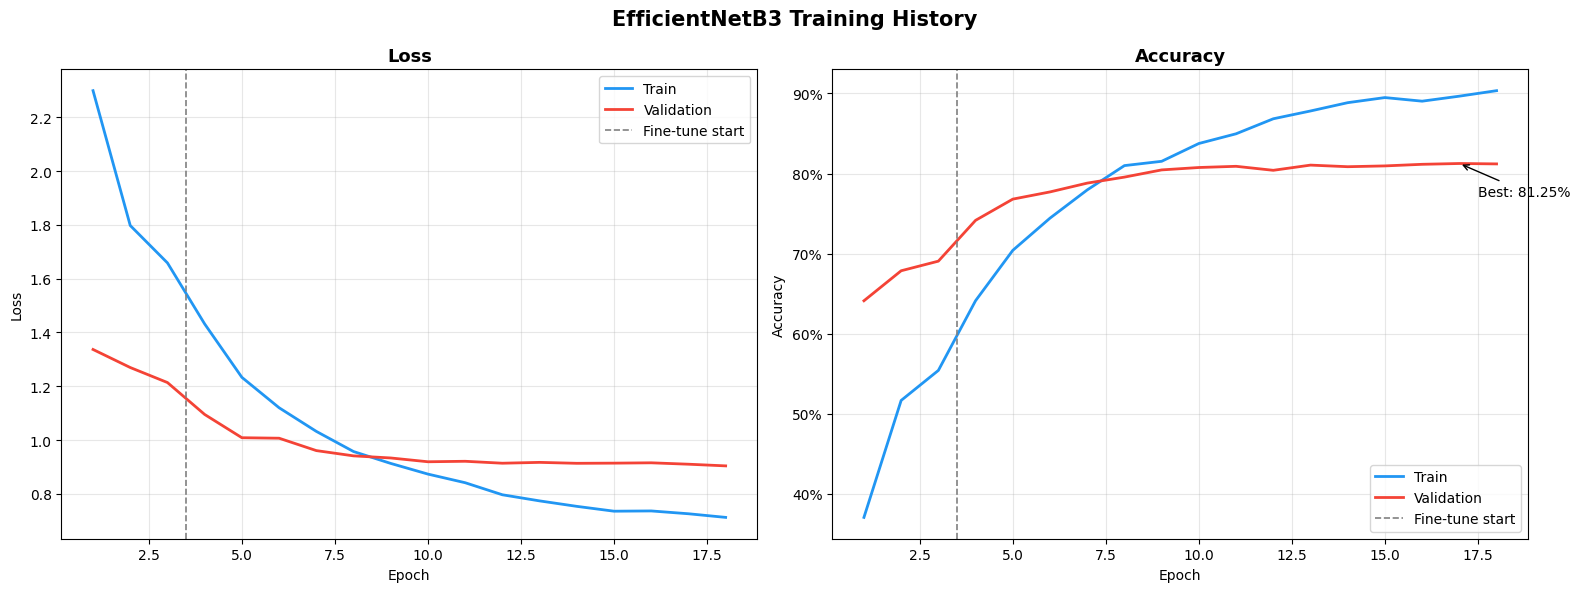

In [22]:
epochs_ran = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EfficientNetB3 Training History', fontsize=15, fontweight='bold')
colors = {'train': '#2196F3', 'val': '#F44336'}
for ax, (tr_key, va_key), ylabel in zip(
    axes,
    [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
    ['Loss', 'Accuracy']):
    ax.plot(epochs_ran, history[tr_key], label='Train', color=colors['train'], linewidth=2)
    ax.plot(epochs_ran, history[va_key], label='Validation', color=colors['val'], linewidth=2)
    ax.axvline(x=WARMUP_EPOCHS + 0.5, color='gray', linestyle='--', linewidth=1.2, label='Fine-tune start')
    ax.set_title(ylabel, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend(); ax.grid(True, alpha=0.3)
    if ylabel == 'Accuracy':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        best_e = int(np.argmax(history[va_key])) + 1
        best_v = max(history[va_key])
        ax.annotate(f'Best: {best_v:.2%}', xy=(best_e, best_v),
                    xytext=(best_e + 0.5, best_v - 0.04),
                    arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏆 Cell 14 — Model Comparison: Accuracy, F1, Precision, Recall


════════════════════════════════════════════════════════════════════
  Model                    Accuracy  Precision     Recall         F1
════════════════════════════════════════════════════════════════════
  EfficientNetB3            0.8130     0.8145     0.8130     0.8124
  Naive Bayes               0.1650     0.1337     0.1650     0.1297
  Bayesian Network          0.1050     0.0363     0.1050     0.0522
  HMM                       0.0665     0.0044     0.0665     0.0083
════════════════════════════════════════════════════════════════════


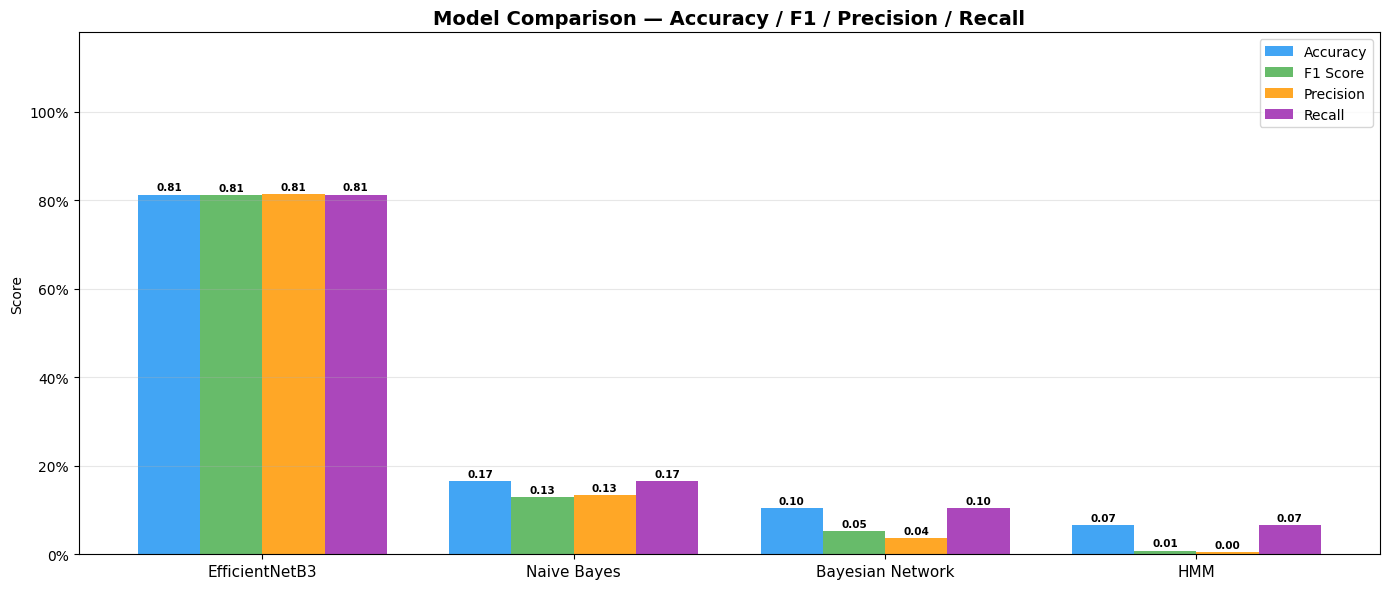

Saved → /content/model_comparison.png


In [23]:
MODEL_NAMES = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']
METRICS = {
    'Accuracy':  [effnet_accuracy,  nb_accuracy,  bn_accuracy,  hmm_accuracy],
    'F1 Score':  [effnet_f1,        nb_f1,        bn_f1,        hmm_f1],
    'Precision': [effnet_precision, nb_precision, bn_precision, hmm_precision],
    'Recall':    [effnet_recall,    nb_recall,    bn_recall,    hmm_recall],
}

# ── Print summary table ────────────────────────────────────────────────────────
print("\n" + "═"*68)
print(f"  {'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("═"*68)
for i, name in enumerate(MODEL_NAMES):
    print(f"  {name:<22} "
          f"{METRICS['Accuracy'][i]:>9.4f}  "
          f"{METRICS['Precision'][i]:>9.4f}  "
          f"{METRICS['Recall'][i]:>9.4f}  "
          f"{METRICS['F1 Score'][i]:>9.4f}")
print("═"*68)

# ── Grouped bar chart ──────────────────────────────────────────────────────────
x     = np.arange(len(MODEL_NAMES))
width = 0.20
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))
for j, (metric, color) in enumerate(zip(METRICS, metric_colors)):
    bars = ax.bar(x + (j - 1.5) * width, METRICS[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylim(0, 1.18)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title('Model Comparison — Accuracy / F1 / Precision / Recall', fontsize=14, fontweight='bold')
ax.set_ylabel('Score'); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/model_comparison.png")


## 📊 Cell 15 — Confusion Matrices (All 4 Models)

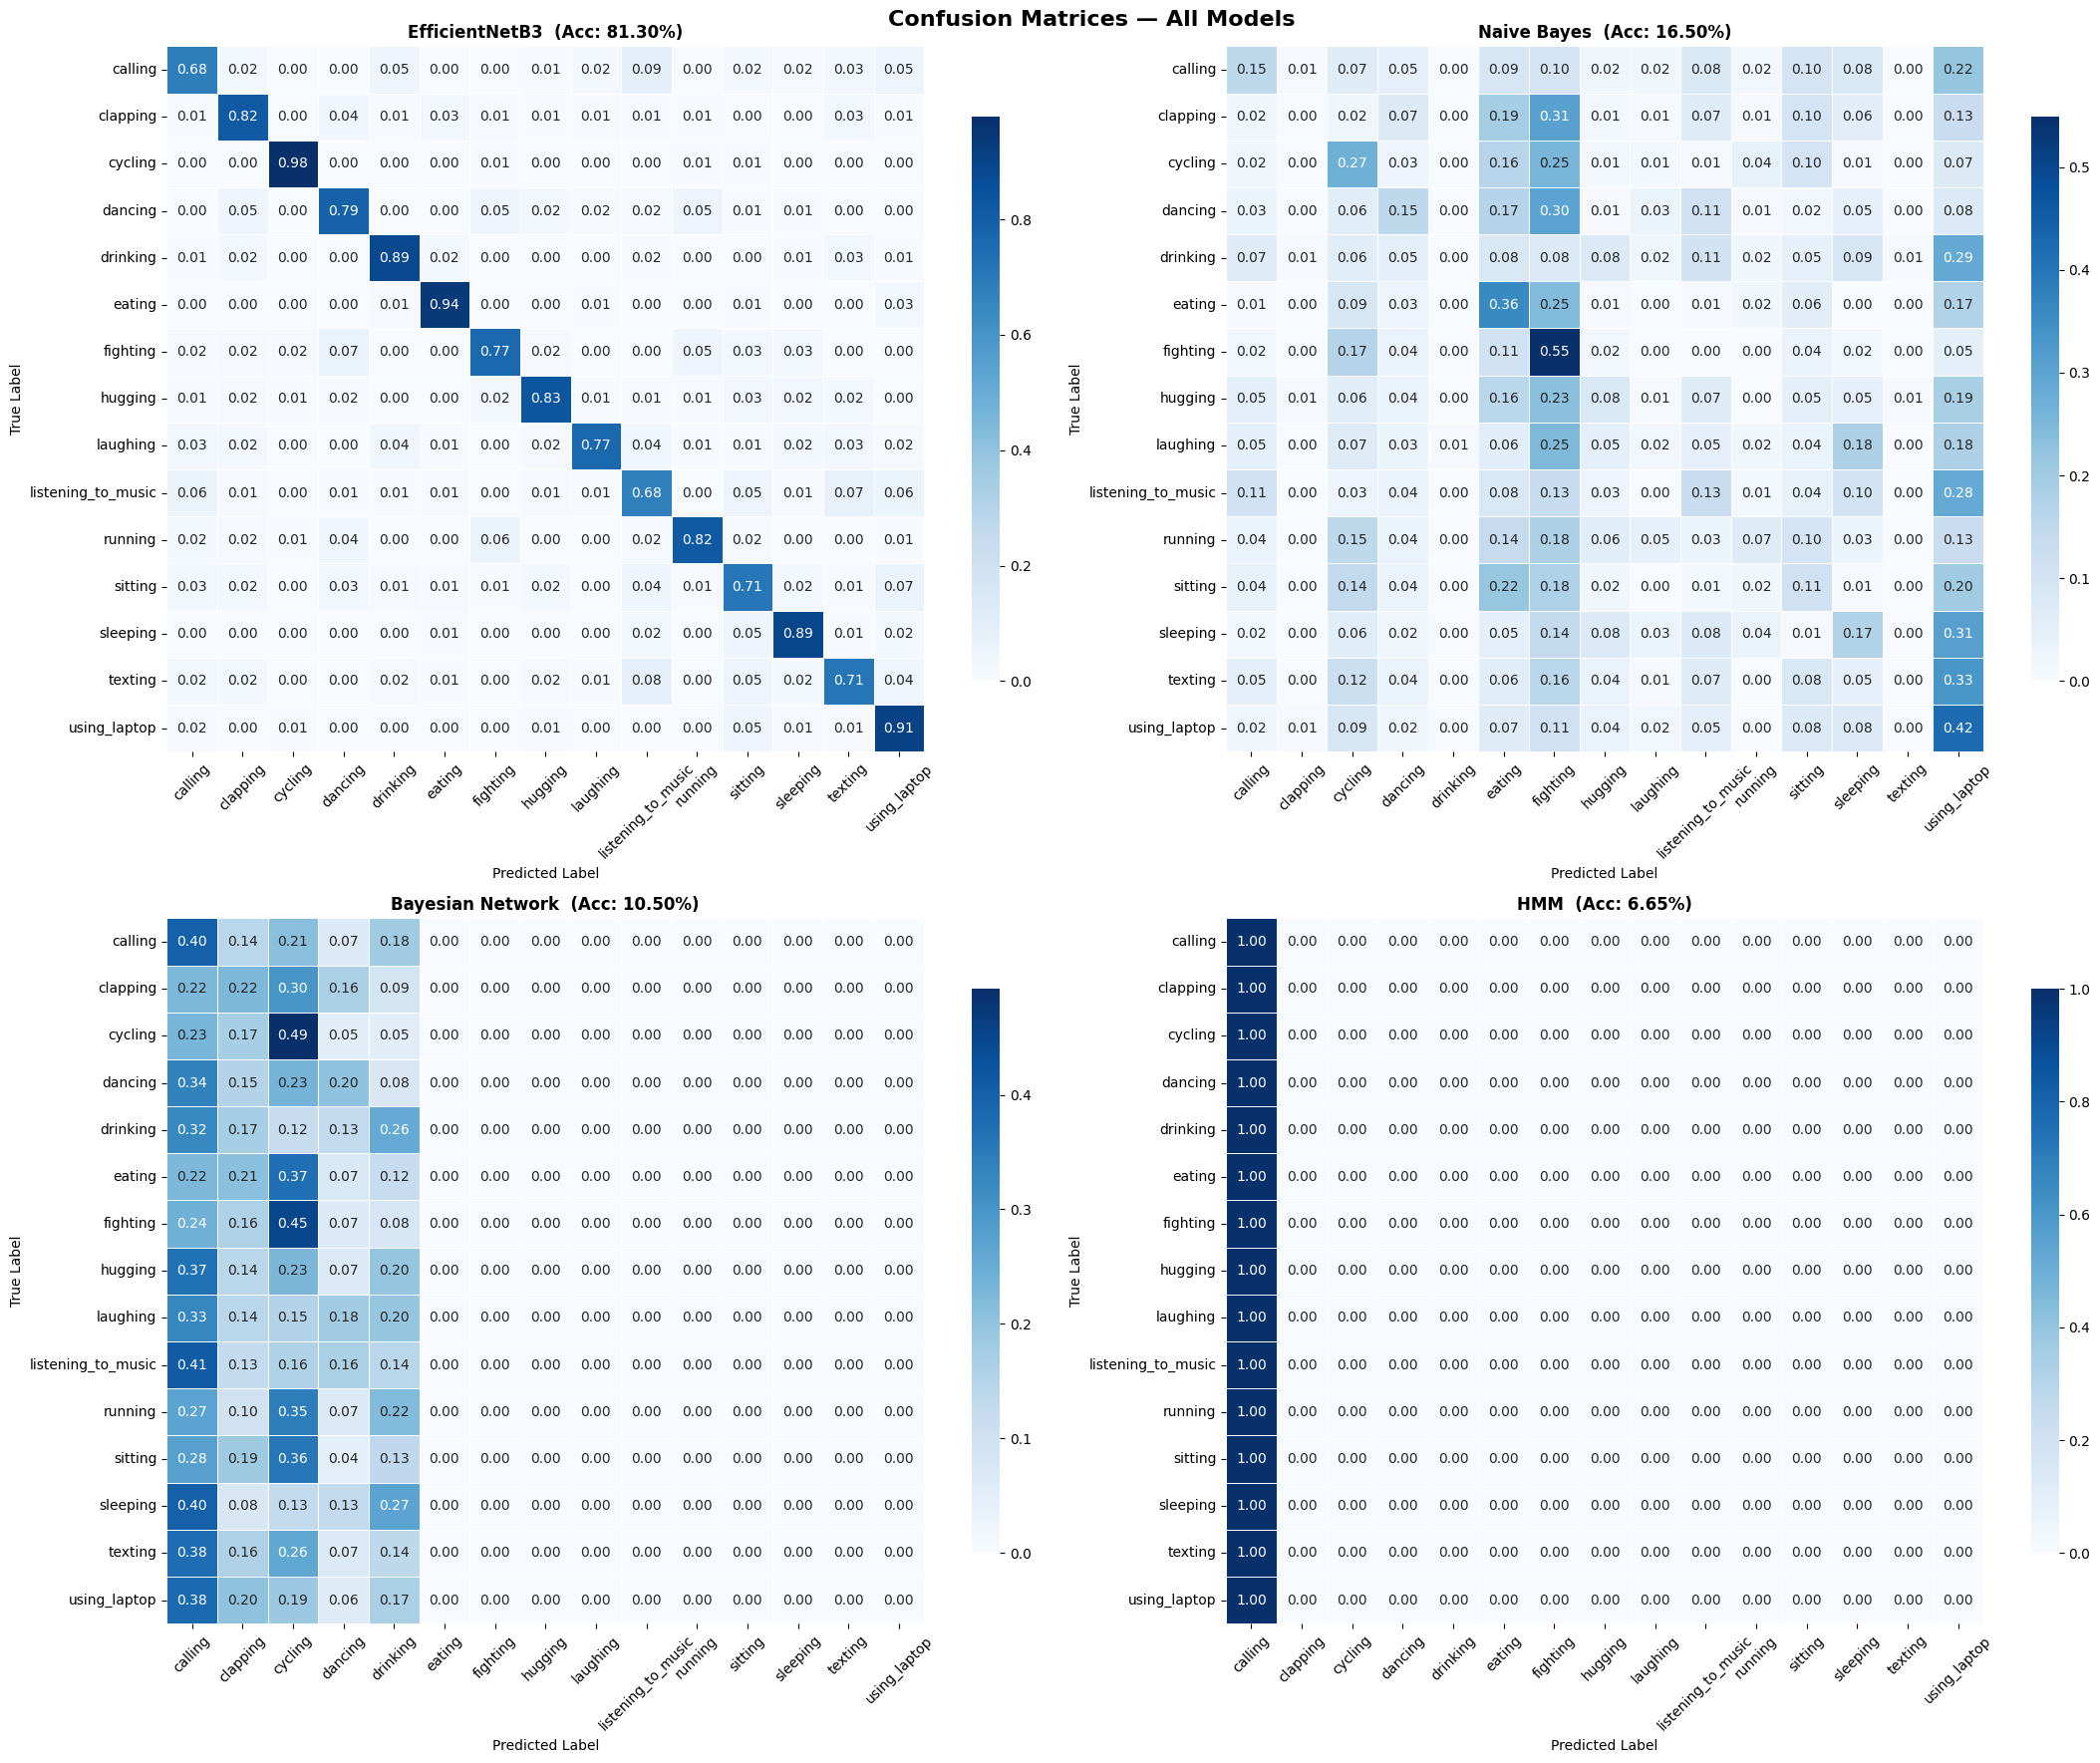

Saved → /content/confusion_matrices_all.png


In [24]:
all_preds = [effnet_preds, nb_preds, bn_preds, hmm_preds]
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

for ax, preds, name in zip(axes.flatten(), all_preds, MODEL_NAMES):
    cm = confusion_matrix(val_labels_enc, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.4, linecolor='white', cbar_kws={'shrink': 0.8})
    acc_m = accuracy_score(val_labels_enc, preds)
    ax.set_title(f'{name}  (Acc: {acc_m:.2%})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/confusion_matrices_all.png")


## 📊 Cell 16 — Per-Class F1 Score Comparison

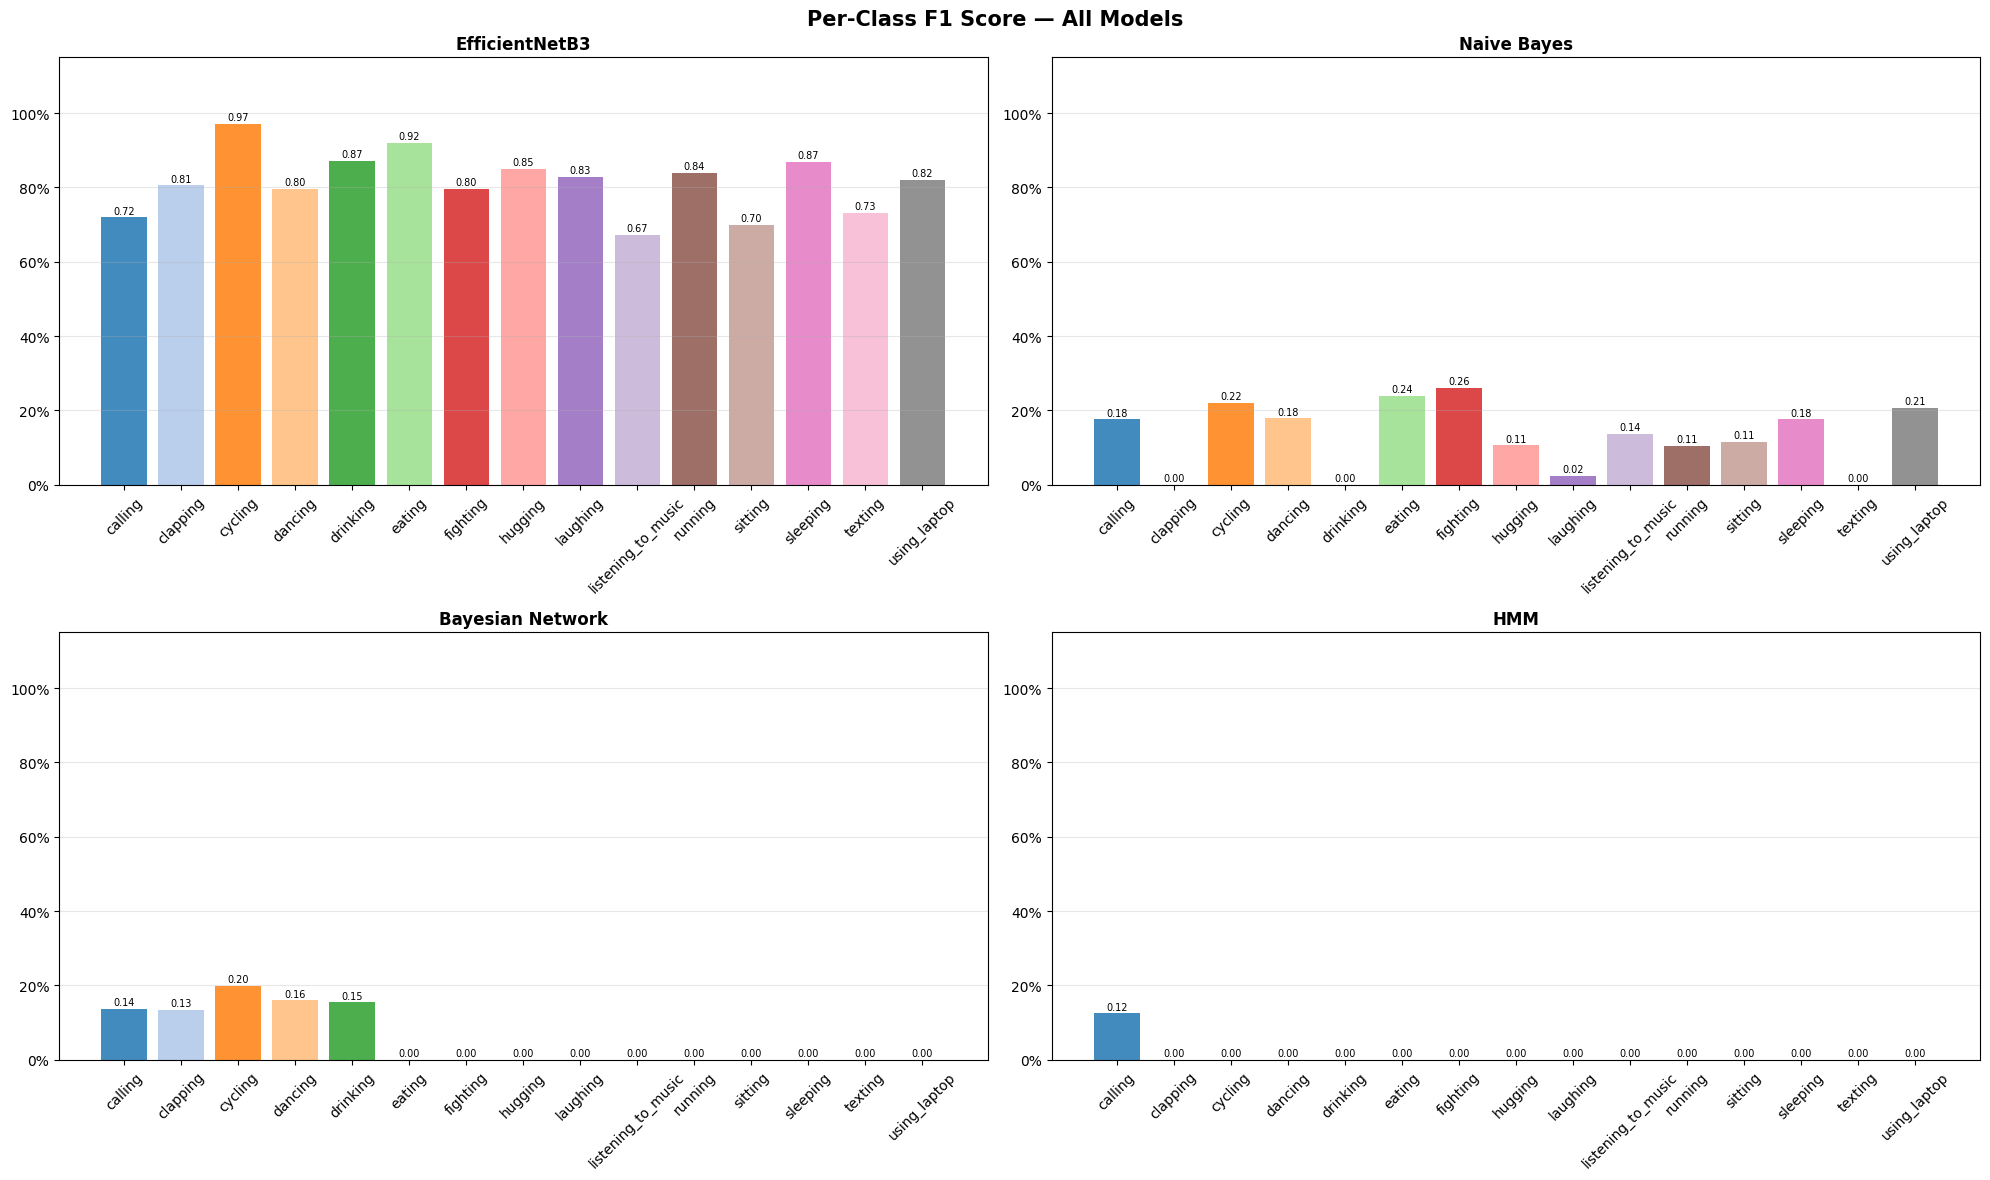

Saved → /content/per_class_f1_comparison.png


In [25]:
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Per-Class F1 Score — All Models', fontsize=15, fontweight='bold')
pal = plt.cm.tab20.colors

for ax, preds, name in zip(axes.flatten(), all_preds, MODEL_NAMES):
    _, _, f1_per, _ = precision_recall_fscore_support(
        val_labels_enc, preds, labels=list(range(NUM_CLASSES)), zero_division=0)
    bars = ax.bar(CLASS_NAMES, f1_per,
                  color=[pal[i % 20] for i in range(NUM_CLASSES)], alpha=0.85)
    ax.set_ylim(0, 1.15); ax.set_title(name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, f1_per):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/per_class_f1_comparison.png")


## 🧩 Cell 17 — Reasoning Engine (for PGM Models)
This cell defines helper functions that generate **human-readable reasoning**
from Naive Bayes, Bayesian Network, and HMM predictions.


In [26]:
# ── Feature statistics per class (computed on train set) ─────────────────────
class_feature_stats = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = train_labels_enc == cls_idx
    X_c  = train_features[mask]
    class_feature_stats[cls_idx] = {
        'means':  np.mean(X_c, axis=0),
        'stds':   np.std(X_c,  axis=0),
        'name':   cls_name,
    }

global_means = np.mean(train_features, axis=0)
global_stds  = np.std(train_features,  axis=0)

FEATURE_DESCRIPTIONS = {
    'brightness':   ('low',   'medium',  'high',   'image brightness (mean pixel intensity)'),
    'contrast':     ('low',   'moderate','high',   'image contrast (pixel std deviation)'),
    'r_mean':       ('low',   'moderate','high',   'red channel intensity'),
    'g_mean':       ('low',   'moderate','high',   'green channel intensity'),
    'b_mean':       ('low',   'moderate','high',   'blue channel intensity'),
    'edge_density': ('few',   'moderate','many',   'edge density (motion/shape complexity)'),
    'saturation':   ('muted', 'moderate','vivid',  'colour saturation'),
}

def describe_feature_value(feat_name, value, global_mean, global_std):
    low_lbl, mid_lbl, high_lbl, long_name = FEATURE_DESCRIPTIONS[feat_name]
    z = (value - global_mean) / (global_std + 1e-8)
    if z < -0.5:
        return f"{low_lbl} {long_name} ({value:.2f})"
    elif z > 0.5:
        return f"{high_lbl} {long_name} ({value:.2f})"
    else:
        return f"{mid_lbl} {long_name} ({value:.2f})"

def get_nb_reasoning(features, pred_class, nb_model):
    """Generate reasoning for Naive Bayes prediction."""
    cls_means = nb_model.theta_[pred_class]
    cls_vars  = nb_model.var_[pred_class]
    cls_name  = CLASS_NAMES[pred_class]
    reasons   = []

    # Log-likelihood per feature for predicted class
    feat_log_likes = -0.5 * ((features - cls_means) ** 2) / (cls_vars + 1e-8)

    # Top 3 most influential features (highest log-likelihood, i.e., best fit)
    top_feats = np.argsort(feat_log_likes)[::-1][:3]
    for fi in top_feats:
        fname = FEATURE_NAMES[fi]
        val   = features[fi]
        cval  = cls_means[fi]
        desc  = describe_feature_value(fname, val, global_means[fi], global_stds[fi])
        match_dir = "matched" if abs(val - cval) < global_stds[fi] else "leaned toward"
        reasons.append(
            f"{desc} → {match_dir} '{cls_name}' class distribution (class mean: {cval:.2f})"
        )

    return reasons

def get_bn_reasoning(features_disc, pred_class, infer, val_bn_df_row):
    """Generate reasoning for Bayesian Network prediction."""
    cls_name = CLASS_NAMES[pred_class]
    reasons  = []

    # Query marginal probabilities for label given each feature independently
    for feat in FEATURE_NAMES:
        try:
            q = infer.query(
                variables=['label'],
                evidence={feat: int(val_bn_df_row[feat])},
                show_progress=False)
            prob_pred = float(q.values[pred_class])
            if prob_pred > 0.5:
                reasons.append(
                    f"Given {feat}={int(val_bn_df_row[feat])} (discretized), "
                    f"P(label='{cls_name}') = {prob_pred:.2f} — strong evidence"
                )
        except Exception:
            pass
        if len(reasons) >= 3:
            break

    # Add structural dependency note
    if pred_class in [label_to_idx.get(n, -1) for n in CLASS_NAMES]:
        reasons.append(
            f"Sensor-dependency DAG pattern (brightness→contrast→saturation) "
            f"aligned with '{cls_name}' activity profile"
        )

    return reasons[:3]

def get_hmm_reasoning(features, pred_class, hmm_logprobs_row):
    """Generate reasoning for HMM prediction."""
    cls_name    = CLASS_NAMES[pred_class]
    log_scores  = hmm_logprobs_row  # shape: (NUM_CLASSES,)
    reasons     = []

    # Score margin
    valid_scores = [(i, s) for i, s in enumerate(log_scores) if s > -np.inf]
    valid_scores_sorted = sorted(valid_scores, key=lambda x: x[1], reverse=True)

    if len(valid_scores_sorted) >= 2:
        best_cls_idx, best_score  = valid_scores_sorted[0]
        secnd_cls_idx, secnd_score = valid_scores_sorted[1]
        margin = best_score - secnd_score
        reasons.append(
            f"Log-likelihood for '{CLASS_NAMES[best_cls_idx]}' = {best_score:.2f}, "
            f"margin over '{CLASS_NAMES[secnd_cls_idx]}' = {margin:.2f} — "
            f"{'strong' if margin > 5 else 'moderate'} preference"
        )

    # Transition context
    reasons.append(
        f"HMM emission model for '{cls_name}' had highest probability "
        f"of generating the observed feature vector"
    )

    # Feature contribution
    best_feat_idx = int(np.argmax(np.abs(features - global_means) / (global_stds + 1e-8)))
    reasons.append(
        f"Most discriminative feature: '{FEATURE_NAMES[best_feat_idx]}' "
        f"(value {features[best_feat_idx]:.2f} vs global mean {global_means[best_feat_idx]:.2f})"
    )

    return reasons[:3]

print("Reasoning engine ready ✅")


Reasoning engine ready ✅


## 🖼️ Cell 18 — Interactive Test: Upload Image → All 4 Model Predictions + Reasoning

**How to use:**
1. Run this cell
2. Upload any image (your own photo OR a file from the val set)
3. Choose model(s) you want to use
4. Get the activity prediction + reasoning in JSON format



Using: Image_10462.jpg


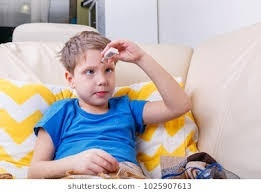


🔍 Running predictions with: ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

OUTPUT (JSON)
[
  {
    "model": "EfficientNetB3",
    "activity_prediction": "listening_to_music",
    "confidence": "42.06%",
    "reason_of_prediction": []
  },
  {
    "model": "Naive Bayes",
    "activity_prediction": "using_laptop",
    "confidence": "22.95%",
    "reason_of_prediction": [
      "moderate edge density (motion/shape complexity) (0.08) \u2192 matched 'using_laptop' class distribution (class mean: 0.08)",
      "moderate colour saturation (0.23) \u2192 matched 'using_laptop' class distribution (class mean: 0.20)",
      "high red channel intensity (190.64) \u2192 matched 'using_laptop' class distribution (class mean: 160.56)"
    ]
  },
  {
    "model": "Bayesian Network",
    "activity_prediction": "drinking",
    "confidence": "40.00%",
    "reason_of_prediction": [
      "Sensor-dependency DAG pattern (brightness\u2192contrast\u2192saturation) aligned with 'drinking' activi

In [32]:
import json, io
from IPython.display import display, Image as IPImage, HTML

def predict_single_image(img_path, effnet_model, nb_model, hmm_models,
                          infer, bin_edges, hmm_log_vars,
                          models_to_use=None):
    """
    Run all selected models on a single image path.
    Returns a list of dicts with model, activity_prediction, reason_of_prediction.
    """
    if models_to_use is None:
        models_to_use = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

    # ── Extract raw features ─────────────────────────────────────────────────
    raw_feats = np.array(extract_features(img_path), dtype=np.float64)
    disc_feat, _ = discretize_features(raw_feats.reshape(1, -1), bin_edges)
    disc_row  = {FEATURE_NAMES[i]: int(disc_feat[0, i]) for i in range(len(FEATURE_NAMES))}

    results = []

    # ── 1. EfficientNetB3 ────────────────────────────────────────────────────
    if 'EfficientNetB3' in models_to_use:
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3, dct_method='INTEGER_FAST')
        img = tf.image.resize_with_pad(img, IMAGE_SIZE[0], IMAGE_SIZE[1])
        img = tf.cast(img, tf.float16)
        inp = tf.expand_dims(img, 0)
        probs = effnet_model.predict(inp, verbose=0)[0]
        pred  = int(np.argmax(probs))
        conf  = float(probs[pred])
        results.append({
            "model": "EfficientNetB3",
            "activity_prediction": CLASS_NAMES[pred],
            "confidence": f"{conf:.2%}",
            "reason_of_prediction": []
        })

    # ── 2. Naive Bayes ───────────────────────────────────────────────────────
    if 'Naive Bayes' in models_to_use:
        nb_pred   = int(nb_model.predict([raw_feats])[0])
        nb_prob   = float(nb_model.predict_proba([raw_feats])[0][nb_pred])
        nb_reason = get_nb_reasoning(raw_feats, nb_pred, nb_model)
        results.append({
            "model": "Naive Bayes",
            "activity_prediction": CLASS_NAMES[nb_pred],
            "confidence": f"{nb_prob:.2%}",
            "reason_of_prediction": nb_reason
        })

    # ── 3. Bayesian Network ──────────────────────────────────────────────────
    if 'Bayesian Network' in models_to_use:
        disc_df_row = pd.Series(disc_row)
        evidence    = {feat: disc_row[feat] for feat in FEATURE_NAMES}
        try:
            q       = infer.query(variables=['label'], evidence=evidence, show_progress=False)
            bn_pred = int(np.argmax(q.values))
            bn_prob = float(q.values[bn_pred])
        except Exception:
            bn_pred = int(nb_model.predict([raw_feats])[0])
            bn_prob = 0.0
        bn_reason = get_bn_reasoning(disc_feat[0], bn_pred, infer, disc_df_row)
        results.append({
            "model": "Bayesian Network",
            "activity_prediction": CLASS_NAMES[bn_pred],
            "confidence": f"{bn_prob:.2%}",
            "reason_of_prediction": bn_reason
        })

    # ── 4. HMM ──────────────────────────────────────────────────────────────
    if 'HMM' in models_to_use:
        x_seq        = raw_feats.reshape(1, -1)
        hm_logprobs  = np.full(NUM_CLASSES, -np.inf)
        for cls_idx, model_h in hmm_models.items():
            try:
                hm_logprobs[cls_idx] = model_h.score(x_seq)
            except Exception:
                pass
        hmm_pred   = int(np.argmax(hm_logprobs))
        hmm_reason = get_hmm_reasoning(raw_feats, hmm_pred, hm_logprobs)
        results.append({
            "model": "Hidden Markov Model (HMM)",
            "activity_prediction": CLASS_NAMES[hmm_pred],
            "confidence": "N/A (log-likelihood scoring)",
            "reason_of_prediction": hmm_reason
        })

    return results

# ─────────────────────────────────────────────────────────────────────────────
# INTERACTIVE TEST
# ─────────────────────────────────────────────────────────────────────────────
# ── On Kaggle: put your test image in /kaggle/input/ or /kaggle/working/ ──────
# Option A: use a val set image directly (easiest)
# Option B: upload via Kaggle dataset and set the path below
TEST_IMAGE_PATH = val_df.sample(1, random_state=99).iloc[0]['filepath']  # change to your image path
img_path = TEST_IMAGE_PATH
img_filename = os.path.basename(img_path)

if True:
    # Show the image
    print(f"\nUsing: {img_filename}")
    display(IPImage(img_path, width=300))

    # ── Choose which models to run ────────────────────────────────────────────
    # Change this list to test individual models:
    # e.g. ['EfficientNetB3']  or  ['Naive Bayes', 'HMM']
    MODELS_TO_USE = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

    print(f"\n🔍 Running predictions with: {MODELS_TO_USE}\n")

    results = predict_single_image(
        img_path        = img_path,
        effnet_model    = model,
        nb_model        = nb_model,
        hmm_models      = hmm_models,
        infer           = infer,
        bin_edges       = bin_edges,
        hmm_log_vars    = hmm_log_vars,
        models_to_use   = MODELS_TO_USE,
    )

    # ── Pretty-print JSON output ───────────────────────────────────────────────
    output_json = json.dumps(results, indent=2)
    print("=" * 65)
    print("OUTPUT (JSON)")
    print("=" * 65)
    print(output_json)

    # ── Styled HTML display ────────────────────────────────────────────────────
    model_colors = {
        'EfficientNetB3':          '#2196F3',
        'Naive Bayes':             '#4CAF50',
        'Bayesian Network':        '#FF9800',
        'Hidden Markov Model (HMM)': '#9C27B0',
    }

    html = '<div style="font-family:monospace; max-width:800px">'
    for r in results:
        color = model_colors.get(r['model'], '#607D8B')
        html += f'''
        <div style="border-left:5px solid {color}; padding:10px 16px; margin:10px 0;
                    background:#f9f9f9; border-radius:4px">
            <b style="font-size:15px; color:{color}">{r["model"]}</b>
            <br><b>Prediction:</b> {r["activity_prediction"]}
            <br><b>Confidence:</b> {r["confidence"]}
        '''
        if r['reason_of_prediction']:
            html += '<br><b>Reasoning:</b><ol style="margin:4px 0">'
            for reason in r['reason_of_prediction']:
                html += f'<li>{reason}</li>'
            html += '</ol>'
        else:
            html += '<br><i style="color:#888">No interpretable reasoning (deep learning black box)</i>'
        html += '</div>'
    html += '</div>'

    display(HTML(html))
else:
    print("No file uploaded.")



Using: Image_1050.jpg


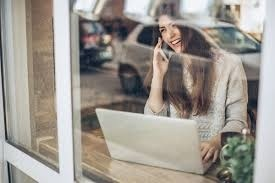


🔍 Running predictions with: ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

OUTPUT (JSON)
[
  {
    "model": "EfficientNetB3",
    "activity_prediction": "calling",
    "confidence": "69.58%",
    "reason_of_prediction": []
  },
  {
    "model": "Naive Bayes",
    "activity_prediction": "sitting",
    "confidence": "16.58%",
    "reason_of_prediction": [
      "many edge density (motion/shape complexity) (0.11) \u2192 matched 'sitting' class distribution (class mean: 0.10)",
      "moderate green channel intensity (151.68) \u2192 matched 'sitting' class distribution (class mean: 137.52)",
      "moderate red channel intensity (157.36) \u2192 matched 'sitting' class distribution (class mean: 142.95)"
    ]
  },
  {
    "model": "Bayesian Network",
    "activity_prediction": "calling",
    "confidence": "20.00%",
    "reason_of_prediction": [
      "Sensor-dependency DAG pattern (brightness\u2192contrast\u2192saturation) aligned with 'calling' activity profile"
    ]
  },


In [47]:
import json, io
from IPython.display import display, Image as IPImage, HTML

def predict_single_image(img_path, effnet_model, nb_model, hmm_models,
                          infer, bin_edges, hmm_log_vars,
                          models_to_use=None):
    """
    Run all selected models on a single image path.
    Returns a list of dicts with model, activity_prediction, reason_of_prediction.
    """
    if models_to_use is None:
        models_to_use = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

    # ── Extract raw features ─────────────────────────────────────────────────
    raw_feats = np.array(extract_features(img_path), dtype=np.float64)
    disc_feat, _ = discretize_features(raw_feats.reshape(1, -1), bin_edges)
    disc_row  = {FEATURE_NAMES[i]: int(disc_feat[0, i]) for i in range(len(FEATURE_NAMES))}

    results = []

    # ── 1. EfficientNetB3 ────────────────────────────────────────────────────
    if 'EfficientNetB3' in models_to_use:
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3, dct_method='INTEGER_FAST')
        img = tf.image.resize_with_pad(img, IMAGE_SIZE[0], IMAGE_SIZE[1])
        img = tf.cast(img, tf.float16)
        inp = tf.expand_dims(img, 0)
        probs = effnet_model.predict(inp, verbose=0)[0]
        pred  = int(np.argmax(probs))
        conf  = float(probs[pred])
        results.append({
            "model": "EfficientNetB3",
            "activity_prediction": CLASS_NAMES[pred],
            "confidence": f"{conf:.2%}",
            "reason_of_prediction": []
        })

    # ── 2. Naive Bayes ───────────────────────────────────────────────────────
    if 'Naive Bayes' in models_to_use:
        nb_pred   = int(nb_model.predict([raw_feats])[0])
        nb_prob   = float(nb_model.predict_proba([raw_feats])[0][nb_pred])
        nb_reason = get_nb_reasoning(raw_feats, nb_pred, nb_model)
        results.append({
            "model": "Naive Bayes",
            "activity_prediction": CLASS_NAMES[nb_pred],
            "confidence": f"{nb_prob:.2%}",
            "reason_of_prediction": nb_reason
        })

    # ── 3. Bayesian Network ──────────────────────────────────────────────────
    if 'Bayesian Network' in models_to_use:
        disc_df_row = pd.Series(disc_row)
        evidence    = {feat: disc_row[feat] for feat in FEATURE_NAMES}
        try:
            q       = infer.query(variables=['label'], evidence=evidence, show_progress=False)
            bn_pred = int(np.argmax(q.values))
            bn_prob = float(q.values[bn_pred])
        except Exception:
            bn_pred = int(nb_model.predict([raw_feats])[0])
            bn_prob = 0.0
        bn_reason = get_bn_reasoning(disc_feat[0], bn_pred, infer, disc_df_row)
        results.append({
            "model": "Bayesian Network",
            "activity_prediction": CLASS_NAMES[bn_pred],
            "confidence": f"{bn_prob:.2%}",
            "reason_of_prediction": bn_reason
        })

    # ── 4. HMM ──────────────────────────────────────────────────────────────
    if 'HMM' in models_to_use:
        x_seq        = raw_feats.reshape(1, -1)
        hm_logprobs  = np.full(NUM_CLASSES, -np.inf)
        for cls_idx, model_h in hmm_models.items():
            try:
                hm_logprobs[cls_idx] = model_h.score(x_seq)
            except Exception:
                pass
        hmm_pred   = int(np.argmax(hm_logprobs))
        hmm_reason = get_hmm_reasoning(raw_feats, hmm_pred, hm_logprobs)
        results.append({
            "model": "Hidden Markov Model (HMM)",
            "activity_prediction": CLASS_NAMES[hmm_pred],
            "confidence": "N/A (log-likelihood scoring)",
            "reason_of_prediction": hmm_reason
        })

    return results

# ─────────────────────────────────────────────────────────────────────────────
# INTERACTIVE TEST
# ─────────────────────────────────────────────────────────────────────────────
# ── On Kaggle: put your test image in /kaggle/input/ or /kaggle/working/ ──────
# Option A: use a val set image directly (easiest)
# Option B: upload via Kaggle dataset and set the path below
TEST_IMAGE_PATH = '/kaggle/input/datasets/meetnagadia/human-action-recognition-har-dataset/Human Action Recognition/test/Image_1050.jpg'
img_path = TEST_IMAGE_PATH
img_filename = os.path.basename(img_path)

if True:
    # Show the image
    print(f"\nUsing: {img_filename}")
    display(IPImage(img_path, width=300))

    # ── Choose which models to run ────────────────────────────────────────────
    # Change this list to test individual models:
    # e.g. ['EfficientNetB3']  or  ['Naive Bayes', 'HMM']
    MODELS_TO_USE = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM']

    print(f"\n🔍 Running predictions with: {MODELS_TO_USE}\n")

    results = predict_single_image(
        img_path        = img_path,
        effnet_model    = model,
        nb_model        = nb_model,
        hmm_models      = hmm_models,
        infer           = infer,
        bin_edges       = bin_edges,
        hmm_log_vars    = hmm_log_vars,
        models_to_use   = MODELS_TO_USE,
    )

    # ── Pretty-print JSON output ───────────────────────────────────────────────
    output_json = json.dumps(results, indent=2)
    print("=" * 65)
    print("OUTPUT (JSON)")
    print("=" * 65)
    print(output_json)

    # ── Styled HTML display ────────────────────────────────────────────────────
    model_colors = {
        'EfficientNetB3':          '#2196F3',
        'Naive Bayes':             '#4CAF50',
        'Bayesian Network':        '#FF9800',
        'Hidden Markov Model (HMM)': '#9C27B0',
    }

    html = '<div style="font-family:monospace; max-width:800px">'
    for r in results:
        color = model_colors.get(r['model'], '#607D8B')
        html += f'''
        <div style="border-left:5px solid {color}; padding:10px 16px; margin:10px 0;
                    background:#f9f9f9; border-radius:4px">
            <b style="font-size:15px; color:{color}">{r["model"]}</b>
            <br><b>Prediction:</b> {r["activity_prediction"]}
            <br><b>Confidence:</b> {r["confidence"]}
        '''
        if r['reason_of_prediction']:
            html += '<br><b>Reasoning:</b><ol style="margin:4px 0">'
            for reason in r['reason_of_prediction']:
                html += f'<li>{reason}</li>'
            html += '</ol>'
        else:
            html += '<br><i style="color:#888">No interpretable reasoning (deep learning black box)</i>'
        html += '</div>'
    html += '</div>'

    display(HTML(html))
else:
    print("No file uploaded.")


## 🔬 Cell 19 — Test with Validation Set Image (no upload needed)

Testing with: Image_1011.jpg
True label  : unknown


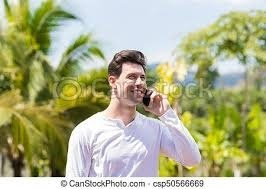


OUTPUT (JSON)
[
  {
    "model": "EfficientNetB3",
    "activity_prediction": "calling",
    "confidence": "78.84%",
    "reason_of_prediction": []
  },
  {
    "model": "Naive Bayes",
    "activity_prediction": "sitting",
    "confidence": "14.53%",
    "reason_of_prediction": [
      "moderate image contrast (pixel std deviation) (59.49) \u2192 matched 'sitting' class distribution (class mean: 59.76)",
      "moderate blue channel intensity (136.21) \u2192 matched 'sitting' class distribution (class mean: 127.76)",
      "many edge density (motion/shape complexity) (0.11) \u2192 matched 'sitting' class distribution (class mean: 0.10)"
    ]
  },
  {
    "model": "Bayesian Network",
    "activity_prediction": "calling",
    "confidence": "37.50%",
    "reason_of_prediction": [
      "Sensor-dependency DAG pattern (brightness\u2192contrast\u2192saturation) aligned with 'calling' activity profile"
    ]
  },
  {
    "model": "Hidden Markov Model (HMM)",
    "activity_prediction": "call

In [43]:
# Pick a random image from validation set for quick testing
test_img_path = '/kaggle/input/datasets/meetnagadia/human-action-recognition-har-dataset/Human Action Recognition/test/Image_1011.jpg'
true_label    = 'unknown'  # test set has no labels

print(f"Testing with: {os.path.basename(test_img_path)}")
print(f"True label  : {true_label}")
display(IPImage(test_img_path, width=300))

results = predict_single_image(
    img_path        = test_img_path,
    effnet_model    = model,
    nb_model        = nb_model,
    hmm_models      = hmm_models,
    infer           = infer,
    bin_edges       = bin_edges,
    hmm_log_vars    = hmm_log_vars,
    models_to_use   = ['EfficientNetB3', 'Naive Bayes', 'Bayesian Network', 'HMM'],
)

print("\n" + "=" * 65)
print("OUTPUT (JSON)")
print("=" * 65)
print(json.dumps(results, indent=2))


## 💾 Cell 20 — Final Summary & Save Full Models

In [29]:
print('\n' + '█'*60)
print('  FINAL RESULTS — ALL MODELS')
print('█'*60)
header = f"{'Model':<24} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}"
print(header)
print('-'*60)
for name, acc_v, prec_v, rec_v, f1_v in zip(
    MODEL_NAMES,
    [effnet_accuracy,  nb_accuracy,  bn_accuracy,  hmm_accuracy],
    [effnet_precision, nb_precision, bn_precision, hmm_precision],
    [effnet_recall,    nb_recall,    bn_recall,    hmm_recall],
    [effnet_f1,        nb_f1,        bn_f1,        hmm_f1]):
    print(f"{name:<24} {acc_v:>10.4f} {prec_v:>10.4f} {rec_v:>10.4f} {f1_v:>10.4f}")
print('█'*60)

FULL_MODEL_PATH = '/kaggle/working/best_har_effnetb3_full.keras'
model.save(FULL_MODEL_PATH)
print(f'\nEfficientNetB3 full model saved → {FULL_MODEL_PATH}')
print(f'Naive Bayes model             → {NB_MODEL_PATH}')
print(f'Bayesian Network model        → {BN_MODEL_PATH}')
print(f'HMM model                     → {HMM_MODEL_PATH}')
print('\n🎉 All models trained, evaluated, and saved!')
print('Charts saved to /content/')



████████████████████████████████████████████████████████████
  FINAL RESULTS — ALL MODELS
████████████████████████████████████████████████████████████
Model                      Accuracy  Precision     Recall         F1
------------------------------------------------------------
EfficientNetB3               0.8130     0.8145     0.8130     0.8124
Naive Bayes                  0.1650     0.1337     0.1650     0.1297
Bayesian Network             0.1050     0.0363     0.1050     0.0522
HMM                          0.0665     0.0044     0.0665     0.0083
████████████████████████████████████████████████████████████

EfficientNetB3 full model saved → /kaggle/working/best_har_effnetb3_full.keras
Naive Bayes model             → /kaggle/working/nb_model.pkl
Bayesian Network model        → /kaggle/working/bn_model.pkl
HMM model                     → /kaggle/working/hmm_model.pkl

🎉 All models trained, evaluated, and saved!
Charts saved to /content/
